In [39]:
#importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [40]:
#reading the data

df = pd.read_csv('popular_people.csv',index_col = 0)
print(df.head())

                   gender known_for_department      original_name  popularity
name                                                                         
Eric Larson             2       Visual Effects        Eric Larson     47.9780
Robert Middlemass       2               Acting  Robert Middlemass     47.8017
María Vaner             1               Acting        María Vaner     47.2016
Carl Wharton            2               Acting       Carl Wharton     36.3365
Victor Moore            2               Acting       Victor Moore     35.9181


In [41]:

# this part converts the data into a normal distribution with mean 0 and standard deviation 1
#needed for KNN to work properly and same for all the features to be on the same scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['popularity']])
print(scaled_features)

[[24.22409313]
 [24.13095669]
 [23.81393357]
 ...
 [-0.31120349]
 [-0.50614022]
 [-0.45320618]]


In [42]:
#creating a dataframe and setting the label and target variable(X,Y)

df_features = pd.DataFrame(scaled_features,columns=['popularity'])
print(df_features.head())


   popularity
0   24.224093
1   24.130957
2   23.813934
3   18.074077
4   17.853043


In [43]:
df = df.reset_index()
df = df.drop_duplicates(subset=['name'])


df = df[df['gender'].isin([1, 2])]

numeric_cols = df.select_dtypes(include=['number']).columns.drop('gender')
scaler = StandardScaler()
df_features = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)


X = df_features
Y = df['gender']


from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [44]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,Y_train)
pred = knn.predict(X_test)
print(pred)

[1 1 2 ... 1 2 1]


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(Y_test,pred))
print(confusion_matrix(Y_test,pred))

df = df.reset_index()

for i in range(1, 3):
    print(f"\n--- Names for Gender ID {i} ---")
    print(df[df['gender'] == i]['name'].head(3))

              precision    recall  f1-score   support

           1       0.47      0.47      0.47      1050
           2       0.54      0.54      0.54      1209

    accuracy                           0.51      2259
   macro avg       0.51      0.51      0.51      2259
weighted avg       0.51      0.51      0.51      2259

[[496 554]
 [554 655]]

--- Names for Gender ID 1 ---
2         María Vaner
5      Sydney Sweeney
7    Julanne Johnston
Name: name, dtype: object

--- Names for Gender ID 2 ---
0          Eric Larson
1    Robert Middlemass
3         Carl Wharton
Name: name, dtype: object


C:\Users\Anirudh G\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21556 (\N{CJK UNIFIED IDEOGRAPH-5434}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Anirudh G\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26790 (\N{CJK UNIFIED IDEOGRAPH-68A6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Anirudh G\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Anirudh G\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33454 (\N{CJK UNIFIED IDEOGRAPH-82AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Anirudh G\AppData\Roaming\Python\Python313\site-packages\IPytho

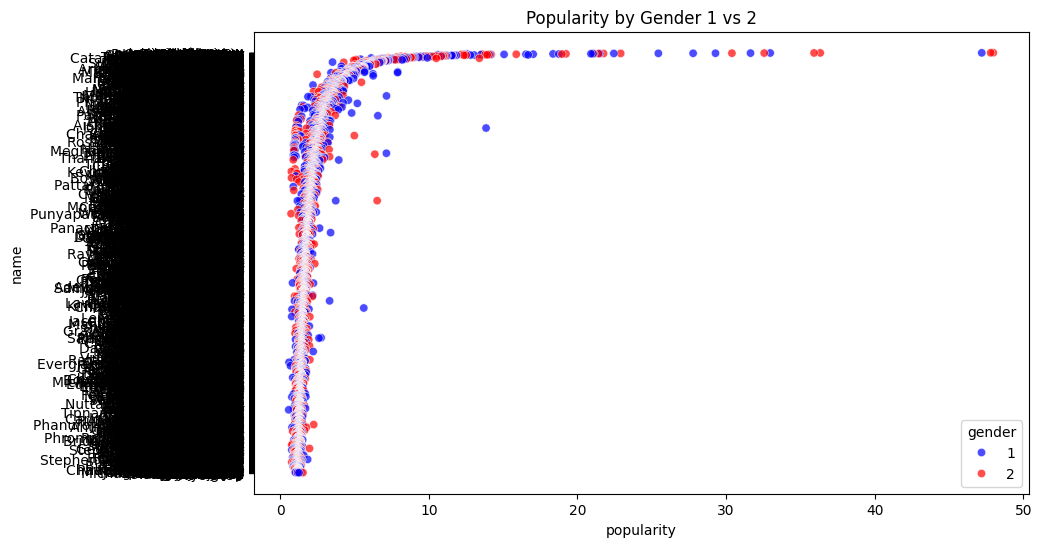

In [50]:

plot_df = df[df['gender'].isin([1, 2])].copy()

plt.figure(figsize=(10, 6))


sns.scatterplot(
    data=plot_df, 
    x='popularity', 
    y='name', 
    hue='gender', 
    palette={1: 'blue', 2: 'red'}, 
    alpha=0.7
)

plt.title('Popularity by Gender 1 vs 2')
plt.show()

In [53]:
print(confusion_matrix(Y_test,pred))


for i in range(1, 3):
    print(f"\n--- Names for Gender ID {i} ---")
    print(df[df['gender'] == i]['name'].head(3))

[[496 554]
 [554 655]]

--- Names for Gender ID 1 ---
2         María Vaner
5      Sydney Sweeney
7    Julanne Johnston
Name: name, dtype: object

--- Names for Gender ID 2 ---
0          Eric Larson
1    Robert Middlemass
3         Carl Wharton
Name: name, dtype: object


Text(0, 0.5, 'Error_rate')

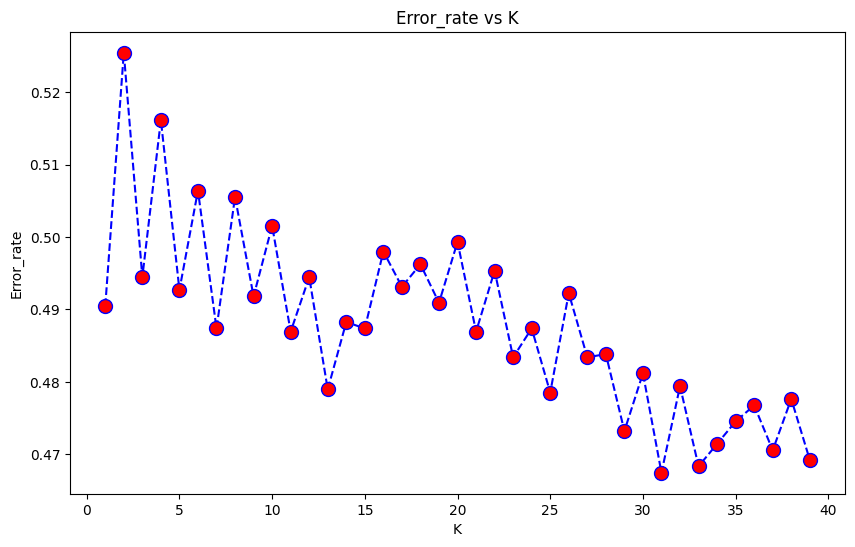

In [ ]:
#error rate for different K values
error_rate = []
for i in range (1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,Y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != Y_test))
plt.figure(figsize=(10,6))
plts = plt.plot(range(1,40),error_rate,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
plt.title('Error_rate vs K')
plt.xlabel('K')
plt.ylabel('Error_rate')